In [ ]:
import numpy as np
import requests
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import time
from tqdm.notebook import tqdm
import os
import gc

# Extraction function

In [ ]:
tiempo_inicio = time.perf_counter()

In [ ]:
# Ensure 'lista_discos.dat' is present in your local path before execution.
with open("lista_discos.dat", "r") as f:
    ID_s = [int(line.strip()) for line in f]

print(ID_s)

In [ ]:
SN_ID = 99
IDS = ID_s[1]
API = userdata.get('TNG_API_KEY')

In [ ]:
def Merger_Tree(SN_ID, ID, API):
    url_MT = f"https://www.tng-project.org/api/TNG50-1/snapshots/{SN_ID}/subhalos/{ID}/sublink/full.hdf5"

    headers = {"api-key":API}
    r_MT = requests.get(url_MT, headers=headers)
    print("STATUS:", r_MT.status_code)

    if r_MT.status_code != 200:
        print(f"Error {r_MT.status_code}")
        return None , r_MT.status_code
    else:
        with open("tree.hdf5", "wb") as f_MT:
            f_MT.write(r_MT.content)
        tree = h5py.File("tree.hdf5", "r")

        snap = tree['SnapNum'][:]
        mass = tree['SubhaloMass'][:]
        subid = tree['SubhaloID'][:]
        subfindID = tree['SubfindID'][:]
        mainLeafID = tree['MainLeafProgenitorID'][0]

        filtro = (subid >= subid[0]) & (subid <= mainLeafID)

        snap_mpb = snap[filtro]
        mass_mpb = mass[filtro]
        subid_mpb = subid[filtro]
        subfindID_mpb = subfindID[filtro]
        tree.close()
        unique_snap = np.unique(snap_mpb)

        return snap_mpb, mass_mpb, subid_mpb, subfindID_mpb, snap, mass, mainLeafID, subid

In [ ]:
def Cut_Out(SN_ID,ID, API):
    url_CO = furl_CO = f"https://www.tng-project.org/api/TNG50-1/snapshots/{SN_ID}/subhalos/{ID}/cutout.hdf5?gas=Coordinates,Density,Masses,MagneticField,InternalEnergy,ElectronAbundance,Velocities,StarFormationRate,GFM_Metals,GFM_Metallicity,GFM_CoolingRate,NeutralHydrogenAbundance,Potential"
    url = f"https://www.tng-project.org/api/TNG50-1/snapshots/{SN_ID}/subhalos/{IDS}/"


    headers = {"api-key":API}

    r_CO = requests.get(url_CO, headers=headers)
    r = requests.get(url, headers=headers)

    if r.status_code == 200:
            data = r.json()
    else:
        print(f"Error {r.status_code}")
        return None , r.status_code

    if r_CO.status_code != 200:
        print(f"Error {r_CO.status_code}")
        return None , r_CO.status_code
    else:
        with open("cutout.hdf5", "wb") as f_CO:
            f_CO.write(r_CO.content)
        f_CO = h5py.File("cutout.hdf5", "r")


        SubhaloCM_x = data['cm_x']
        SubhaloCM_y = data['cm_y']
        SubhaloCM_z = data['cm_z']

        SubhaloPos_x = data['pos_x']
        SubhaloPos_y = data['pos_y']
        SubhaloPos_z = data['pos_z']

        Coord = f_CO['PartType0']['Coordinates'][:]
        Densi = f_CO['PartType0']['Density'][:]
        M_F = f_CO['PartType0']['MagneticField'][:]
        Mass = f_CO['PartType0']['Masses'][:]
        Internal_Energy = f_CO['PartType0']['InternalEnergy'][:]
        Electron_Abundance = f_CO['PartType0']['ElectronAbundance'][:]
        Star_Formation_Rate = f_CO['PartType0']['StarFormationRate'][:]
        V = f_CO['PartType0']['Velocities'][:]
        GFM_Metals = f_CO['PartType0']['GFM_Metals'][:]
        GFM_Metallicity = f_CO['PartType0']['GFM_Metallicity'][:]
        GFM_CoolingRate = f_CO['PartType0']['GFM_CoolingRate'][:]
        NeutralHydrogenAbundance = f_CO['PartType0']['NeutralHydrogenAbundance'][:]
        Potential = f_CO['PartType0']['Potential'][:]
        f_CO.close()
        return Coord, Densi, M_F, Mass, Internal_Energy, Electron_Abundance, Star_Formation_Rate, V , GFM_Metals, GFM_Metallicity, GFM_CoolingRate, NeutralHydrogenAbundance, Potential

In [ ]:
stat = 0
intentos = 0
while stat == 0:
    extrac = Merger_Tree(SN_ID, IDS, API)
    if extrac[0] is None:
      if extrac[1] in [500, 502, 503, 504, 408]:
        stat = 0
        intentos += 1
        time.sleep(5)
        if intentos == 20:
            print(f"No se pudo descargar el ID{IDS}")
            stat = 1
        else:
            continue
      else:
        print(f"No se pudo descargar el ID{IDS}")
        stat = 1
    else:
        stat = 2

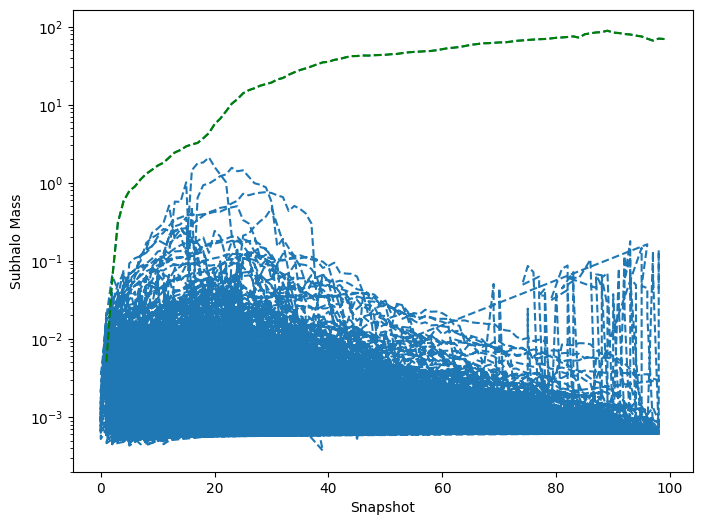

In [ ]:
plt.figure(figsize=(8,6))

#plt.plot(snap, mass,'--',markersize=0.1)
plt.plot(extrac[4], extrac[5],'--',markersize=0.1)
#plt.plot(snap_mpb,mass_mpb,'g--')
plt.plot(extrac[0],extrac[1],'g--')

plt.yscale('log')
plt.xlabel('Snapshot')
plt.ylabel('Subhalo Mass')

plt.show()

In [ ]:
SN_IDs = extrac[0]
SubHaloMasss = extrac[1]
SubHaloIDs = extrac[2]
IDs = extrac[3]

In [ ]:
SN_IDs_Mask = [2,3,4,6,8,11,13,17,21,25,33,40,50,59,67,72,78,84,91,99] ## Solo Full Snaps
mask_full = np.isin(SN_IDs, SN_IDs_Mask)
SN = SN_IDs[mask_full]
SubHaloMass = SubHaloMasss[mask_full]
SubHaloID = SubHaloIDs[mask_full]
ID = IDs[mask_full]

In [ ]:
Xs =[]
Ys =[]
Zs =[]

Density = []

Bxs = []
Bys = []
Bzs = []

Mass = []

Internal_Energy = []

Electron_Abundance = []

Star_Formation_Rate = []

Vx = []
Vy = []
Vz = []

GFM_Metals = []
H = []
He = []
C = []
N = []
O = []
Ne = []
Mg = []
Si = []
Fe = []

GFM_Metallicity = []

GFM_CoolingRate = []

NeutralHydrogenAbundance = []

Potential = []

In [ ]:
nume = list(range(20))

for i in tqdm(nume, desc="Descargando snapshots"):
    stat = 0
    intentos = 0
    while stat == 0:
        CUti = Cut_Out(SN[i], ID[i], API)
        if CUti[0] is None:
          if CUti[1] in [500, 502, 503, 504, 408]:
            stat = 0
            intentos += 1
            time.sleep(5)
            if intentos == 20:
                print(f"No se pudo descargar el snap {SN[i]} con ID{ID[i]}")
                stat = 1
            else:
                continue
          else:
            print(f"No se pudo descargar el snap {SN[i]} con ID{ID[i]}")
            stat = 1
        else:
            stat = 2
    if stat == 2:
      Xs.append(CUti[0][:,0])
      Ys.append(CUti[0][:,1])
      Zs.append(CUti[0][:,2])
      Density.append(CUti[1])
      Bxs.append(CUti[2][:,0])
      Bys.append(CUti[2][:,1])
      Bzs.append(CUti[2][:,2])
      Mass.append(CUti[3])
      Internal_Energy.append(CUti[4])
      Electron_Abundance.append(CUti[5])
      Star_Formation_Rate.append(CUti[6])
      Vx.append(CUti[7][:,0])
      Vy.append(CUti[7][:,1])
      Vz.append(CUti[7][:,2])
      GFM_Metals.append(CUti[8][:,9])
      H.append(CUti[8][:,0])
      He.append(CUti[8][:,1])
      C.append(CUti[8][:,2])
      N.append(CUti[8][:,3])
      O.append(CUti[8][:,4])
      Ne.append(CUti[8][:,5])
      Mg.append(CUti[8][:,6])
      Si.append(CUti[8][:,7])
      Fe.append(CUti[8][:,8])
      GFM_Metallicity.append(CUti[9])
      GFM_CoolingRate.append(CUti[10])
      NeutralHydrogenAbundance.append(CUti[11])
      Potential.append(CUti[12])
    elif stat == 1:
      Xs.append(None)
      Ys.append(None)
      Zs.append(None)
      Density.append(None)
      Bxs.append(None)
      Bys.append(None)
      Bzs.append(None)
      Mass.append(None)
      Internal_Energy.append(None)
      Electron_Abundance.append(None)
      Star_Formation_Rate.append(None)
      Vx.append(None)
      Vy.append(None)
      Vz.append(None)
      GFM_Metals.append(None)
      H.append(None)
      He.append(None)
      C.append(None)
      N.append(None)
      O.append(None)
      Ne.append(None)
      Mg.append(None)
      Si.append(None)
      Fe.append(None)
      GFM_Metallicity.append(None)
      GFM_CoolingRate.append(None)
      NeutralHydrogenAbundance.append(None)
      Potential.append(None)

In [ ]:
np.savez(
    f"Datos_Galaxia{ID[0]}.npz",
    Snap=SN,
    SubfindID=ID,
    X=np.array(Xs, dtype=object),
    Y=np.array(Ys, dtype=object),
    Z=np.array(Zs, dtype=object),
    Density=np.array(Density, dtype=object),
    Bx=np.array(Bxs, dtype=object),
    By=np.array(Bys, dtype=object),
    Bz=np.array(Bzs, dtype=object),
    Mass=np.array(Mass, dtype=object),
    Internal_Energy=np.array(Internal_Energy, dtype=object),
    Electron_Abundance=np.array(Electron_Abundance, dtype=object),
    SFR=np.array(Star_Formation_Rate, dtype=object),
    Vx=np.array(Vx, dtype=object),
    Vy=np.array(Vy, dtype=object),
    Vz=np.array(Vz, dtype=object),
    Total_Metals=np.array(GFM_Metals, dtype=object),
    H=np.array(H, dtype=object),
    He=np.array(He, dtype=object),
    C=np.array(C, dtype=object),
    N=np.array(N, dtype=object),
    O=np.array(O, dtype=object),
    Ne=np.array(Ne, dtype=object),
    Mg=np.array(Mg, dtype=object),
    Si=np.array(Si, dtype=object),
    Fe=np.array(Fe, dtype=object),
    GFM_Metallicity=np.array(GFM_Metallicity, dtype=object),
    GFM_CoolingRate=np.array(GFM_CoolingRate, dtype=object),
    Neutral_H_Abundance=np.array(NeutralHydrogenAbundance, dtype=object),
    Potential=np.array(Potential, dtype=object),
    SubhaloMass=SubHaloMass,
    SubhaloID=SubHaloID
)

In [ ]:
tiempo_total = time.perf_counter() - tiempo_inicio

In [ ]:
print(f"Tiempo total: {tiempo_total:.2f} s")
print(f"Tiempo total: {tiempo_total/60:.2f} min")
print(f"Tiempo total: {tiempo_total/3600:.2f} h")

In [ ]:
archivo = f"Datos_Galaxia{ID[0]}.npz"

print(f"Archivo: {archivo}")
print(f"Tamaño: {os.path.getsize(archivo)/1024**3:.2f} GB")

# CLEAR RAM

In [ ]:
del extrac
del CUti
os.remove("cutout.hdf5")
os.remove("tree.hdf5")
Xs.clear()
Ys.clear()
Zs.clear()
Density.clear()
Bxs.clear()
Bys.clear()
Bzs.clear()
Mass.clear()
Internal_Energy.clear()
Electron_Abundance.clear()
Star_Formation_Rate.clear()
Vx.clear()
Vy.clear()
Vz.clear()
GFM_Metals.clear()
H.clear()
He.clear()
C.clear()
N.clear()
O.clear()
Ne.clear()
Mg.clear()
Si.clear()
Fe.clear()
GFM_Metallicity.clear()
GFM_CoolingRate.clear()
NeutralHydrogenAbundance.clear()
Potential.clear()

gc.collect()